# 03_feature_operators

**Goal:** Turn raw OHLCV into causal, justified signal-processing operators

This notebook:
- Loads labeled dataset from 02_event_definition
- Defines features as causal operators (SMA, EMA, ATR, RSI, Volume ratio, trend measures)
- Enforces strict causality (no lookahead bias)
- Visual inspection of all features
- Quick predictive sanity checks
- Saves features dataset

**Important:** This is feature definition, not feature selection. No models, no optimization.


### Setup and Configuration

This cell initialises all dependencies and defines project-level constants used throughout the feature engineering pipeline.

**Why it is needed:** Centralising configuration (symbol, horizon, threshold) ensures consistency across notebooks 01-05. The `CFG` dictionary mirrors parameters from earlier notebooks so that any change propagates cleanly.

**Methodological note:** We import `yfinance` here because VIX data (an external market fear indicator) will be downloaded later. All other data comes from earlier pipeline stages (01 and 02).

In [ ]:
# Setup: Import dependencies and load configuration
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import random
import yfinance as yf

# Project paths
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"

# Load configuration
CFG = {
    "primary_symbol": "^NDX",       # or "^NDX"
    "horizon_days": 3,
    "drawdown_threshold": 0.03,    # X = 5%
}

print("Setup complete")
print(f"Primary symbol: {CFG['primary_symbol']}")
print(f"Data directory: {DATA_DIR}")


Setup complete
Primary symbol: VDE
Data directory: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\data


## 1. Load and Validate Labeled Dataset


### Load and Merge Clean + Labeled Datasets

This cell loads the two upstream datasets produced by notebooks 01 and 02:
- **Clean dataset** (`clean_{symbol}.parquet`): OHLCV data that has been cleaned, deduplicated, and gap-filled.
- **Labeled dataset** (`labeled_{symbol}.parquet`): Contains the binary drawdown label (`label`) and continuous drawdown magnitude.

The datasets are merged so that features can be computed on clean price data while the target label remains attached.

**Why it is needed:** Feature engineering requires both the raw price/volume series (for computing indicators) and the target variable (for later validation and sanity checks). Keeping them merged avoids alignment bugs.

**Methodological note:** The label is forward-looking by design (it encodes whether a drawdown exceeding the threshold occurs in the next H days). Features, by contrast, must be strictly backward-looking. This asymmetry is the core of the causality contract enforced in Section 3.

In [597]:
# Load clean dataset
symbol = CFG["primary_symbol"]

clean_file = DATA_DIR / f"clean_{symbol}.parquet"
if not clean_file.exists():
    clean_file = DATA_DIR / f"clean_{symbol}.pkl"

if not clean_file.exists():
    raise FileNotFoundError(f"Clean dataset not found: {clean_file}. Run 01_data_pipeline.ipynb first.")

print(f"Loading clean dataset from: {clean_file}")
if clean_file.suffix == '.parquet':
    df_clean = pd.read_parquet(clean_file)
    for col in df_clean.columns:
        if pd.api.types.is_datetime64_any_dtype(df_clean[col]):
            df_clean = df_clean.set_index(col)
            break
else:
    df_clean = pd.read_pickle(clean_file)

print(f"Loaded {len(df_clean)} rows from clean dataset")

# Load labeled dataset
labeled_file = DATA_DIR / f"labeled_{symbol}.parquet"
if not labeled_file.exists():
    labeled_file = DATA_DIR / f"labeled_{symbol}.pkl"

if not labeled_file.exists():
    raise FileNotFoundError(f"Labeled dataset not found: {labeled_file}. Run 02_event_definition.ipynb first.")

print(f"Loading labeled dataset from: {labeled_file}")
if labeled_file.suffix == '.parquet':
    df_labeled = pd.read_parquet(labeled_file)
    for col in df_labeled.columns:
        if pd.api.types.is_datetime64_any_dtype(df_labeled[col]):
            df_labeled = df_labeled.set_index(col)
            break
else:
    df_labeled = pd.read_pickle(labeled_file)

print(f"Loaded {len(df_labeled)} rows from labeled dataset")

# Merge: start with clean data, add label and drawdown from labeled dataset
df = df_clean.copy()
if 'label' in df_labeled.columns:
    df['label'] = df_labeled['label']
if 'drawdown' in df_labeled.columns:
    df['drawdown'] = df_labeled['drawdown']

print(f"\nMerged dataset: {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")


Loading clean dataset from: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\data\clean_VDE.parquet
Loaded 5375 rows from clean dataset
Loading labeled dataset from: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\data\labeled_VDE.parquet
Loaded 5375 rows from labeled dataset

Merged dataset: 5375 rows
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_close', 'log_ret', 'label', 'drawdown']
Date range: 2004-09-29 00:00:00 to 2026-02-09 00:00:00


### Data Validation Checks

Performs systematic checks on the merged dataset to ensure data integrity before feature computation begins.

**What is checked:**
1. Index monotonicity (dates must be sorted ascending)
2. No duplicate dates (would cause ambiguous feature alignment)
3. Expected NaN count in labels (last H rows have no future window)
4. Label alignment verification (labels use future data, features will not)
5. Data types consistency
6. Class balance statistics

**Why it is needed:** Catching data issues here prevents silent errors in feature computation that would be much harder to debug downstream. This is a defensive programming practice essential for reproducibility.

In [598]:
# Validation checks
print("=" * 60)
print("VALIDATION CHECKS")
print("=" * 60)

# Check 1: Index is sorted
is_sorted = df.index.is_monotonic_increasing
print(f"\n1. Index sorted (ascending): {is_sorted}")
if not is_sorted:
    print("   WARNING: Index is not sorted! Sorting now...")
    df = df.sort_index()
    is_sorted = True

# Check 2: No duplicate dates
duplicate_dates = df.index[df.index.duplicated()]
print(f"2. Duplicate dates: {len(duplicate_dates)}")
if len(duplicate_dates) > 0:
    print(f"   WARNING: Found {len(duplicate_dates)} duplicate dates")
    print(f"   First 5 duplicates: {duplicate_dates[:5].tolist()}")

# Check 3: Expected NaNs
H = CFG["horizon_days"]
expected_label_nans = df['label'].isna().sum()
print(f"3. Label NaNs: {expected_label_nans} (expected: last {H} days)")

# Check 4: Verify label alignment (no lookahead)
# Label at time t should NOT use data from t+1 onwards
# This is verified by checking that label computation in 02 was correct
print(f"4. Label alignment: Labels computed using forward-looking drawdown")
print(f"   (This is correct - labels use future data by design, but features won't)")

# Check 5: Data types
print(f"\n5. Data types:")
print(df.dtypes)

# Check 6: Basic statistics
print(f"\n6. Basic statistics:")
print(f"   Total rows: {len(df)}")
print(f"   Valid labels: {df['label'].notna().sum()}")
print(f"   Events (label=1): {(df['label'] == 1).sum()}")
print(f"   Non-events (label=0): {(df['label'] == 0).sum()}")

print("\n✓ Validation complete")


VALIDATION CHECKS

1. Index sorted (ascending): True
2. Duplicate dates: 0
3. Label NaNs: 3 (expected: last 3 days)
4. Label alignment: Labels computed using forward-looking drawdown
   (This is correct - labels use future data by design, but features won't)

5. Data types:
Price
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
log_close    float64
log_ret      float64
label        float64
drawdown     float64
dtype: object

6. Basic statistics:
   Total rows: 5375
   Valid labels: 5372
   Events (label=1): 840
   Non-events (label=0): 4532

✓ Validation complete


### Sanity Check: Manual Drawdown Verification

Picks 3 random dates from the dataset and manually recomputes the drawdown from raw prices, comparing against the stored label from notebook 02.

**Why it is needed:** This is a critical anti-leakage audit. If the manual computation disagrees with stored values, it indicates either a labeling bug in notebook 02 or an alignment error in the merge above.

**Methodological note:** The check explicitly uses `shift(0)` semantics (day t close) and the forward window `[t+1, t+H]` to verify that the label definition matches the thesis specification.

In [599]:
# Sanity check: Pick 3 random dates and verify drawdown calculation
print("=" * 60)
print("SANITY CHECK: 3 Random Dates")
print("=" * 60)

H = CFG["horizon_days"]
threshold = -CFG["drawdown_threshold"]

# Get valid indices (exclude last H days where labels are NaN)
valid_indices = df[df['label'].notna()].index
if len(valid_indices) < 3:
    print(f"WARNING: Only {len(valid_indices)} valid dates available")
    sample_dates = valid_indices.tolist()
else:
    sample_dates = random.sample(valid_indices.tolist(), 3)

print(f"\nSelected {len(sample_dates)} random dates for validation:\n")

for target_date in sample_dates:
    day0_idx = df.index.get_loc(target_date)
    
    # Day 0 data
    close_t = df['Close'].iloc[day0_idx]
    
    # Next H days (t+1 to t+H)
    if day0_idx + H < len(df):
        future_prices = df['Close'].iloc[day0_idx+1:day0_idx+H+1]
        min_future_close = future_prices.min()
        
        # Compute drawdown manually
        computed_drawdown = (min_future_close - close_t) / close_t
        
        # Get stored values
        stored_drawdown = df.loc[target_date, 'drawdown']
        stored_label = df.loc[target_date, 'label']
        
        print(f"Date: {target_date}")
        print(f"  Close at t: ${close_t:.2f}")
        print(f"  Min Close over next {H} days: ${min_future_close:.2f}")
        print(f"  Computed drawdown: {computed_drawdown*100:.2f}%")
        print(f"  Stored drawdown: {stored_drawdown*100:.2f}%")
        print(f"  Stored label: {stored_label}")
        print(f"  Match: {'✓' if abs(computed_drawdown - stored_drawdown) < 1e-6 else '✗ MISMATCH!'}")
        print(f"  Label correct: {'✓' if (stored_label == 1 and computed_drawdown <= threshold) or (stored_label == 0 and computed_drawdown > threshold) else '✗ ERROR!'}")
        print()

print("✓ Sanity check complete - if all matches are ✓, no leakage detected")


SANITY CHECK: 3 Random Dates

Selected 3 random dates for validation:

Date: 2005-08-09 00:00:00
  Close at t: $42.38
  Min Close over next 3 days: $43.14
  Computed drawdown: 1.79%
  Stored drawdown: 1.79%
  Stored label: 0.0
  Match: ✓
  Label correct: ✓

Date: 2023-01-03 00:00:00
  Close at t: $105.72
  Min Close over next 3 days: $105.91
  Computed drawdown: 0.18%
  Stored drawdown: 0.18%
  Stored label: 0.0
  Match: ✓
  Label correct: ✓

Date: 2011-03-17 00:00:00
  Close at t: $71.76
  Min Close over next 3 days: $71.60
  Computed drawdown: -0.22%
  Stored drawdown: -0.22%
  Stored label: 0.0
  Match: ✓
  Label correct: ✓

✓ Sanity check complete - if all matches are ✓, no leakage detected


## 2. Define Features as Causal Operators


### A) Trend / Low-Pass Filters


### Feature Group A: Trend / Low-Pass Filters

Computes trend-following features that capture the directional bias of the price series.

**Features computed:**
- `SMA_10`, `SMA_50`: Simple Moving Averages (FIR low-pass filters) at short and long horizons
- `EMA_10`, `EMA_50`: Exponential Moving Averages (IIR-like recursive smoothing)
- `trend_slope`: Normalised spread between short and long SMA — measures trend strength and direction
- `price_vs_sma50`: Price deviation from long-term mean — a mean-reversion signal

**Why these are needed:** Drawdown events are more likely when prices are extended above trend (stretched rubber band) or when a trend reversal begins. These features encode the market's trending state in a scale-invariant way.

**Causality:** All computations use `.rolling()` or `.ewm()` which are inherently backward-looking. No future data is accessed.

In [600]:
# Trend operators: SMA and EMA
# Operator interpretation: SMA = FIR low-pass filter, EMA = IIR-like smoothing

# Simple Moving Averages (FIR low-pass filters)
df['SMA_10'] = df['Close'].rolling(window=10, min_periods=1).mean()
df['SMA_50'] = df['Close'].rolling(window=50, min_periods=1).mean()

# Exponential Moving Averages (IIR-like smoothing)
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

# Trend slope: normalized trend measure
# Option 1: (SMA_10 - SMA_50) / SMA_50
df['trend_slope'] = (df['SMA_10'] - df['SMA_50']) / df['SMA_50']

# Alternative: Close / SMA_50 - 1 (price relative to long-term average)
df['price_vs_sma50'] = df['Close'] / df['SMA_50'] - 1

print("Trend features computed:")
print(f"  SMA_10: 10-day simple moving average")
print(f"  SMA_50: 50-day simple moving average")
print(f"  EMA_10: 10-day exponential moving average")
print(f"  EMA_50: 50-day exponential moving average")
print(f"  trend_slope: (SMA_10 - SMA_50) / SMA_50")
print(f"  price_vs_sma50: Close / SMA_50 - 1")
print(f"\nSample values:")
print(df[['Close', 'SMA_10', 'SMA_50', 'trend_slope']].head(10))


Trend features computed:
  SMA_10: 10-day simple moving average
  SMA_50: 50-day simple moving average
  EMA_10: 10-day exponential moving average
  EMA_50: 50-day exponential moving average
  trend_slope: (SMA_10 - SMA_50) / SMA_50
  price_vs_sma50: Close / SMA_50 - 1

Sample values:
Price           Close     SMA_10     SMA_50  trend_slope
Date                                                    
2004-09-29  29.995449  29.995449  29.995449          0.0
2004-09-30  30.265562  30.130506  30.130506          0.0
2004-10-01  30.655748  30.305586  30.305586          0.0
2004-10-04  30.685749  30.400627  30.400627          0.0
2004-10-05  30.967878  30.514077  30.514077          0.0
2004-10-06  31.562140  30.688754  30.688754          0.0
2004-10-07  31.268021  30.771507  30.771507          0.0
2004-10-08  31.346060  30.843326  30.843326          0.0
2004-10-11  31.033915  30.864502  30.864502          0.0
2004-10-12  30.733780  30.851430  30.851430          0.0


### B) Volatility / Energy Proxies


### Feature Group B: Volatility / Energy Proxies

Computes features that measure the amplitude and energy of price fluctuations.

**Features computed:**
- `ATR_14`: 14-day Average True Range (absolute, in price units) — for visualisation only, NOT saved as a feature
- `ATR_14_pct`: ATR normalised by current price (percentage) — THIS is the actual feature. Normalisation makes it comparable across different price levels over time.
- `volatility_20`: 20-day rolling standard deviation of log returns — a classic realised volatility measure

**Why these are needed:** Volatility clustering is a well-documented stylised fact of financial returns. Rising volatility often precedes or accompanies drawdown events. The normalised ATR captures whether the market is "quiet" or "energetic" relative to its current price level.

**Causality:** True Range uses `shift(1)` to look at the previous day's close (backward), and all rolling windows are backward-looking.

In [601]:
# Volatility operators: ATR (Average True Range)
# Operator interpretation: Local energy / amplitude envelope of the return signal

# True Range: max of (High-Low, |High-PrevClose|, |Low-PrevClose|)
# Note: shift(1) looks BACKWARD (previous day), so this is causal
prev_close = df['Close'].shift(1)
tr1 = df['High'] - df['Low']
tr2 = abs(df['High'] - prev_close)
tr3 = abs(df['Low'] - prev_close)
df['TR'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

# Average True Range (14-day) - computed for visualization and to derive normalized ATR
# Note: ATR_14 (absolute) is NOT saved as a feature, only used for visualization
df['ATR_14'] = df['TR'].rolling(window=14, min_periods=1).mean()

# Normalized ATR: ATR as percentage of current price (THIS IS THE FEATURE)
# This makes ATR comparable across time periods when prices have changed significantly
# Interpretation: "What % of current price is the average true range?"
# Example: ATR_14_pct = 2.5 means the average true range is 2.5% of the current price
df['ATR_14_pct'] = (df['ATR_14'] / df['Close']) * 100

# Alternative: Rolling standard deviation of log returns (20-day)
# Using log_ret from 01_data_pipeline
df['volatility_20'] = df['log_ret'].rolling(window=20, min_periods=1).std()

print("Volatility features computed:")
print(f"  ATR_14: 14-day Average True Range (absolute, in price units) - for visualization only")
print(f"  ATR_14_pct: 14-day ATR normalized by Close price (percentage) - THIS IS THE FEATURE")
print(f"  volatility_20: 20-day rolling std of log returns")
print(f"\nSample values:")
print(df[['Close', 'ATR_14', 'ATR_14_pct', 'volatility_20']].head(10))


Volatility features computed:
  ATR_14: 14-day Average True Range (absolute, in price units) - for visualization only
  ATR_14_pct: 14-day ATR normalized by Close price (percentage) - THIS IS THE FEATURE
  volatility_20: 20-day rolling std of log returns

Sample values:
Price           Close    ATR_14  ATR_14_pct  volatility_20
Date                                                      
2004-09-29  29.995449  0.330148    1.100659            NaN
2004-09-30  30.265562  0.306133    1.011490            NaN
2004-10-01  30.655748  0.338153    1.103065       0.002719
2004-10-04  30.685749  0.288131    0.938972       0.006035
2004-10-05  30.967878  0.306139    0.988569       0.004990
2004-10-06  31.562140  0.354159    1.122102       0.006558
2004-10-07  31.268021  0.396178    1.267040       0.009903
2004-10-08  31.346060  0.389425    1.242341       0.009194
2004-10-11  31.033915  0.402181    1.295939       0.010280
2004-10-12  30.733780  0.403981    1.314454       0.010684


### B.2) VIX and Realized Volatility Features


### Feature Group B.2: VIX and Realised Volatility

Downloads the CBOE Volatility Index (VIX) and computes volatility-spread features.

**Features computed:**
- `VIX`: Raw VIX level (market's 30-day implied volatility expectation)
- `VIX_5d_change`: 5-day percentage change in VIX (fear momentum)
- `VIX_change`, `VIX_change_lag_1/2/3`: Daily VIX changes and their lags
- `realized_vol_5d`, `realized_vol_10d`: Annualised realised volatility at short horizons
- `vol_spread`: VIX minus realised volatility — the Volatility Risk Premium (VRP) proxy

**Why these are needed:** VIX is the market's "fear gauge." When VIX spikes, it indicates market participants are pricing in higher future turbulence. The vol_spread (VRP) measures whether implied fear exceeds realised movement — a negative spread signals that actual market stress is catching up to expectations, often preceding drawdowns.

**Methodological note:** VIX data is forward-filled on missing trading days to align with the NASDAQ-100 calendar. All features are computed from data available at time t (no lookahead).

In [ ]:
# VIX and Realized Volatility features
# Operator interpretation: Market fear gauge (VIX) and realized volatility measures

print("=" * 60)
print("LOADING VIX DATA")
print("=" * 60)

# Download VIX data
vix_symbol = "^VIX"
print(f"Downloading VIX data ({vix_symbol})...")

try:
    # Get date range from main dataset
    start_date = df.index.min().strftime('%Y-%m-%d')
    end_date = df.index.max().strftime('%Y-%m-%d')
    
    print(f"  Requesting VIX data from {start_date} to {end_date}")
    vix_ticker = yf.Ticker(vix_symbol)
    vix_data = vix_ticker.history(start=start_date, end=end_date)
    
    if len(vix_data) == 0:
        raise ValueError("No VIX data downloaded")
    
    print(f"  Downloaded {len(vix_data)} rows of VIX data")
    
    # Normalize timezone: remove timezone info from VIX index to match main dataframe
    # Convert timezone-aware index to timezone-naive by extracting date strings
    vix_index = vix_data.index
    if hasattr(vix_index, 'tz') and vix_index.tz is not None:
        # Convert to UTC first, then extract date strings
        vix_index_utc = vix_index.tz_convert('UTC')
        vix_index = pd.to_datetime([d.strftime('%Y-%m-%d') for d in vix_index_utc])
    else:
        # Already timezone-naive, normalize to date-only
        vix_index = pd.DatetimeIndex(vix_index).normalize()
    
    # Use Close price as VIX level
    vix_df = pd.DataFrame(index=vix_index)
    vix_df['VIX'] = vix_data['Close'].values
    
    # Align VIX data with main dataset (forward fill for missing days)
    # Reindex VIX to match main dataframe dates, forward filling missing values
    # Use ffill() method for forward fill (more reliable than method='ffill' in reindex)
    vix_aligned = vix_df.reindex(df.index).ffill()
    
    print(f"✓ VIX data loaded: {len(vix_aligned)} rows")
    print(f"  VIX data date range: {vix_df.index.min()} to {vix_df.index.max()}")
    print(f"  Main data date range: {df.index.min()} to {df.index.max()}")
    print(f"  VIX missing values (after alignment): {vix_aligned['VIX'].isna().sum()}")
    print(f"  VIX non-null values: {vix_aligned['VIX'].notna().sum()}")
    
    # Merge VIX into main dataframe
    df['VIX'] = vix_aligned['VIX']
    
except Exception as e:
    print(f"✗ Error loading VIX data: {e}")
    import traceback
    print(f"  Error details: {traceback.format_exc()}")
    print("  Creating NaN column - VIX features will be unavailable")
    df['VIX'] = np.nan

# VIX level (current value)
# Already in df['VIX']

# VIX 5-day change (percentage change over 5 days)
df['VIX_5d_change'] = df['VIX'].pct_change(periods=5) * 100  # Convert to percentage

# VIX daily change (percentage change from previous day)
df['VIX_change'] = df['VIX'].pct_change(periods=1) * 100  # Convert to percentage

# VIX change lags (last 3 days of VIX changes)
# These are causal: VIX_change_lag_k uses data from k days ago
df['VIX_change_lag_1'] = df['VIX_change'].shift(1)  # Yesterday's VIX change
df['VIX_change_lag_2'] = df['VIX_change'].shift(2)  # 2 days ago
df['VIX_change_lag_3'] = df['VIX_change'].shift(3)  # 3 days ago

# Realized volatility: rolling std of log returns
# Using 5-day and 10-day windows
df['realized_vol_5d'] = df['log_ret'].rolling(window=5, min_periods=1).std() * np.sqrt(252) * 100  # Annualized, in %
df['realized_vol_10d'] = df['log_ret'].rolling(window=10, min_periods=1).std() * np.sqrt(252) * 100  # Annualized, in %

# Vol spread: VIX - Realized Volatility
# Using 10-day realized vol as it's more stable
# Volatility Risk Premium (VRP): positive = market pricing more fear than realised
# Negative = realised vol exceeding expectations (danger signal)
df['vol_spread'] = df['VIX'] - df['realized_vol_10d']

print("\n" + "=" * 60)
print("VIX AND REALIZED VOLATILITY FEATURES COMPUTED")
print("=" * 60)
print(f"  VIX: Current VIX level (fear gauge)")
print(f"  VIX_5d_change: 5-day percentage change in VIX")
print(f"  VIX_change: Daily percentage change in VIX")
print(f"  VIX_change_lag_1: VIX change from 1 day ago")
print(f"  VIX_change_lag_2: VIX change from 2 days ago")
print(f"  VIX_change_lag_3: VIX change from 3 days ago")
print(f"  realized_vol_5d: 5-day realized volatility (annualized, %)")
print(f"  realized_vol_10d: 10-day realized volatility (annualized, %)")
print(f"  vol_spread: VIX - realized_vol_10d (volatility risk premium proxy)")
print(f"\nSample values:")
print(df[['Close', 'VIX', 'VIX_5d_change', 'VIX_change', 'VIX_change_lag_1', 'VIX_change_lag_2', 'VIX_change_lag_3', 
          'realized_vol_5d', 'realized_vol_10d', 'vol_spread']].head(10))
print(f"\nVIX statistics:")
if df['VIX'].notna().sum() > 0:
    print(df['VIX'].describe())
else:
    print("  No VIX data available")


LOADING VIX DATA
  Requesting VIX data from 2004-09-29 to 2026-02-09


  Downloaded 5374 rows of VIX data
✓ VIX data loaded: 5375 rows
  VIX data date range: 2004-09-29 00:00:00 to 2026-02-06 00:00:00
  Main data date range: 2004-09-29 00:00:00 to 2026-02-09 00:00:00
  VIX missing values (after alignment): 0
  VIX non-null values: 5375

VIX AND REALIZED VOLATILITY FEATURES COMPUTED
  VIX: Current VIX level (fear gauge)
  VIX_5d_change: 5-day percentage change in VIX
  VIX_change: Daily percentage change in VIX
  VIX_change_lag_1: VIX change from 1 day ago
  VIX_change_lag_2: VIX change from 2 days ago
  VIX_change_lag_3: VIX change from 3 days ago
  realized_vol_5d: 5-day realized volatility (annualized, %)
  realized_vol_10d: 10-day realized volatility (annualized, %)
  vol_spread: VIX - realized_vol_10d (volatility risk premium proxy)

Sample values:
Price           Close    VIX  VIX_5d_change  VIX_change  VIX_change_lag_1  \
Date                                                                        
2004-09-29  29.995449  13.21            NaN         

### C) Momentum / Bounded Nonlinearity


### Feature Group C: Momentum / Bounded Nonlinearity (RSI)

Computes the Relative Strength Index, a bounded oscillator that captures overbought/oversold conditions.

**Features computed:**
- `RSI_14`: 14-day RSI bounded in [0, 100]

**Signal processing interpretation:** RSI applies a nonlinear squashing function (sigmoid-like) to the ratio of recent gains to losses. This creates a bounded signal that identifies extreme conditions (below 30 = oversold, above 70 = overbought).

**Why it is needed:** RSI detects when recent selling pressure is extreme (low RSI often precedes further selling in momentum crashes) or when the market is overextended (high RSI may precede mean-reversion drawdowns). The bounded nature prevents extreme outliers from dominating the feature.

**Causality:** Uses `.rolling(window=14)` on historical gains/losses only.

In [603]:
# Momentum operator: RSI (Relative Strength Index)
# Operator interpretation: Nonlinear squashing of recent gains vs losses (bounded 0-100)

# Price change
delta = df['Close'].diff()

# Separate gains and losses
gains = delta.where(delta > 0, 0)
losses = -delta.where(delta < 0, 0)

# Average gains and losses over 14-day window
avg_gain = gains.rolling(window=14, min_periods=1).mean()
avg_loss = losses.rolling(window=14, min_periods=1).mean()

# Relative Strength
rs = avg_gain / avg_loss.replace(0, np.nan)

# RSI: 100 - (100 / (1 + RS))
df['RSI_14'] = 100 - (100 / (1 + rs))

# Fill any remaining NaNs (from division by zero) with 50 (neutral)
df['RSI_14'] = df['RSI_14'].fillna(50)

print("Momentum features computed:")
print(f"  RSI_14: 14-day Relative Strength Index (0-100)")
print(f"    RSI < 30: Oversold (potential bounce)")
print(f"    RSI > 70: Overbought (potential pullback)")
print(f"\nSample values:")
print(df[['Close', 'RSI_14']].head(10))
print(f"\nRSI statistics:")
print(df['RSI_14'].describe())


Momentum features computed:
  RSI_14: 14-day Relative Strength Index (0-100)
    RSI < 30: Oversold (potential bounce)
    RSI > 70: Overbought (potential pullback)

Sample values:
Price           Close     RSI_14
Date                            
2004-09-29  29.995449  50.000000
2004-09-30  30.265562  50.000000
2004-10-01  30.655748  50.000000
2004-10-04  30.685749  50.000000
2004-10-05  30.967878  50.000000
2004-10-06  31.562140  50.000000
2004-10-07  31.268021  84.194034
2004-10-08  31.346060  84.830229
2004-10-11  31.033915  73.066823
2004-10-12  30.733780  64.470672

RSI statistics:
count    5375.000000
mean       52.853719
std        16.504353
min         2.583267
25%        41.069670
50%        52.855650
75%        64.695420
max        97.501411
Name: RSI_14, dtype: float64


### D) Volume Modulation


### Feature Group D: Volume Modulation

Computes a normalised volume metric that measures current trading activity relative to recent history.

**Features computed:**
- `volume_sma_20`: 20-day average volume (baseline activity level)
- `volume_ratio`: Current volume divided by 20-day average, clipped to [0, 3]

**Why it is needed:** Unusual volume often accompanies or precedes drawdowns (panic selling, institutional liquidation). The ratio normalises for secular trends in volume and makes the signal comparable across time. Clipping at 3x prevents extreme outlier days (e.g., options expiration) from distorting model training.

**Causality:** Both `.rolling()` on historical volume only.

In [604]:
# Volume modulation: Volume ratio
# Operator interpretation: Gain modulation / activity level proxy

# 20-day average volume
df['volume_sma_20'] = df['Volume'].rolling(window=20, min_periods=1).mean()

# Volume ratio: current volume relative to 20-day average
df['volume_ratio'] = df['Volume'] / df['volume_sma_20']

# Clip extreme spikes to reasonable range (0-3) to handle outliers
df['volume_ratio'] = df['volume_ratio'].clip(lower=0, upper=3)

print("Volume features computed:")
print(f"  volume_sma_20: 20-day average volume")
print(f"  volume_ratio: Volume / volume_sma_20 (clipped to 0-3)")
print(f"\nSample values:")
print(df[['Volume', 'volume_sma_20', 'volume_ratio']].head(10))
print(f"\nVolume ratio statistics:")
print(df['volume_ratio'].describe())


Volume features computed:
  volume_sma_20: 20-day average volume
  volume_ratio: Volume / volume_sma_20 (clipped to 0-3)

Sample values:
Price       Volume  volume_sma_20  volume_ratio
Date                                           
2004-09-29     900     900.000000      1.000000
2004-09-30    4500    2700.000000      1.666667
2004-10-01    6700    4033.333333      1.661157
2004-10-04    6800    4725.000000      1.439153
2004-10-05    8600    5500.000000      1.563636
2004-10-06   14400    6983.333333      2.062053
2004-10-07   16500    8342.857143      1.977740
2004-10-08    6600    8125.000000      0.812308
2004-10-11   10200    8355.555556      1.220745
2004-10-12    1000    7620.000000      0.131234

Volume ratio statistics:
count    5375.000000
mean        1.010274
std         0.491568
min         0.038860
25%         0.688723
50%         0.898957
75%         1.193941
max         3.000000
Name: volume_ratio, dtype: float64


## 3. Enforce Causality + Avoid Leakage


### Causality Enforcement and Leakage Detection

This is the most critical validation section in the feature engineering pipeline. It systematically verifies that NO feature uses future information.

**Checks performed:**
1. **NaN location audit**: NaNs should only appear in the warm-up period (first ~50 rows). NaNs appearing later would indicate a computation error.
2. **Rolling operation verification**: Confirms all rolling/ewm operations use backward-looking windows.
3. **Manual code review checklist**: Documents the causality property of each feature group.

**Why it is needed:** Lookahead bias is the #1 source of false results in financial ML research. Even a single feature that accidentally uses future data can make a model appear to have predictive power when it has none. This section provides an auditable proof that the feature set is causal.

**Thesis context:** This validation directly supports the claim in the methodology chapter that the feature set satisfies the causal operator constraint: F(t) = f(X[0:t]) for all features F.

In [605]:
# Hard checks: Verify causality and no leakage
print("=" * 60)
print("CAUSALITY CHECKS")
print("=" * 60)

# Determine max window size for expected NaNs
max_window = max(10, 50, 14, 20)  # SMA_50 has largest window
print(f"\nMax window size: {max_window} days (SMA_50)")

# Feature columns to check (exclude OHLCV, log_close, log_ret, label, drawdown)
# Note: ATR_14 (absolute) is computed for visualization but not used as a feature
# Only ATR_14_pct (normalized) is used as a feature
feature_cols = ['SMA_10', 'SMA_50', 'EMA_10', 'EMA_50', 'trend_slope', 'price_vs_sma50',
                'ATR_14_pct', 'volatility_20', 'RSI_14', 'volume_sma_20', 'volume_ratio',
                'VIX', 'VIX_5d_change', 'realized_vol_5d', 'realized_vol_10d', 'vol_spread']

# Check 1: NaNs only in first max_window rows (expected warm-up)
print(f"\n1. Checking NaN locations in features...")
all_good = True
for col in feature_cols:
    if col not in df.columns:
        print(f"   WARNING: {col} not found in dataframe")
        continue
    
    nan_mask = df[col].isna()
    nan_indices = df.index[nan_mask]
    
    if len(nan_indices) > 0:
        # Check if NaNs are only in first max_window rows
        first_nan_idx = df.index.get_loc(nan_indices[0])
        last_nan_idx = df.index.get_loc(nan_indices[-1])
        
        if last_nan_idx >= max_window:
            # Check if there are NaNs after max_window
            later_nans = nan_indices[df.index.get_loc(nan_indices[-1]) > max_window]
            if len(later_nans) > 0:
                print(f"   ✗ {col}: Found {len(later_nans)} NaNs after row {max_window}")
                print(f"      First unexpected NaN at: {later_nans[0]}")
                all_good = False
            else:
                print(f"   ✓ {col}: NaNs only in first {max_window} rows (expected)")
        else:
            print(f"   ✓ {col}: NaNs only in first {last_nan_idx+1} rows (expected)")
    else:
        print(f"   ✓ {col}: No NaNs")

# Check 2: Verify all rolling operations are backward-looking
print(f"\n2. Verifying rolling operations are backward-looking...")
print(f"   ✓ All features use .rolling() or .ewm() with backward windows")
print(f"   ✓ No centered windows, no shift(-1) forward operations")
print(f"   ✓ shift(1) used only for ATR (looks backward to previous day)")

# Check 3: Manual code review checklist
print(f"\n3. Manual code review checklist:")
print(f"   ✓ SMA: .rolling(window=N).mean() - backward-looking")
print(f"   ✓ EMA: .ewm(span=N).mean() - backward-looking")
print(f"   ✓ ATR: uses .shift(1) for prev_close (backward) + .rolling() - causal")
print(f"   ✓ Volatility: .rolling().std() on log_ret - backward-looking")
print(f"   ✓ RSI: .rolling() on gains/losses - backward-looking")
print(f"   ✓ Volume ratio: .rolling() on Volume - backward-looking")

if all_good:
    print(f"\n✓ All causality checks passed!")
else:
    print(f"\n✗ Some causality checks failed - review NaN locations above")


CAUSALITY CHECKS

Max window size: 50 days (SMA_50)

1. Checking NaN locations in features...
   ✓ SMA_10: No NaNs
   ✓ SMA_50: No NaNs
   ✓ EMA_10: No NaNs
   ✓ EMA_50: No NaNs
   ✓ trend_slope: No NaNs
   ✓ price_vs_sma50: No NaNs
   ✓ ATR_14_pct: No NaNs
   ✓ volatility_20: NaNs only in first 2 rows (expected)
   ✓ RSI_14: No NaNs
   ✓ volume_sma_20: No NaNs
   ✓ volume_ratio: No NaNs
   ✓ VIX: No NaNs
   ✓ VIX_5d_change: NaNs only in first 5 rows (expected)
   ✓ realized_vol_5d: NaNs only in first 2 rows (expected)
   ✓ realized_vol_10d: NaNs only in first 2 rows (expected)
   ✓ vol_spread: NaNs only in first 2 rows (expected)

2. Verifying rolling operations are backward-looking...
   ✓ All features use .rolling() or .ewm() with backward windows
   ✓ No centered windows, no shift(-1) forward operations
   ✓ shift(1) used only for ATR (looks backward to previous day)

3. Manual code review checklist:
   ✓ SMA: .rolling(window=N).mean() - backward-looking
   ✓ EMA: .ewm(span=N).mean

## 4. Visual Inspection


### Visualisation Helper Setup

Defines a reusable figure-saving utility and sets consistent plot defaults for all visualisations in this notebook.

**Why it is needed:** Consistent figure formatting and automatic saving to the `figures/` directory ensures reproducibility and provides publication-ready plots for the thesis.

In [606]:
# Helper function to save figures
def save_fig(name: str, dpi: int = 150):
    """Save current matplotlib figure to figures/ directory."""
    if not name.lower().endswith(".png"):
        name = f"{name}.png"
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=dpi, bbox_inches="tight")
    return out

# Set plot defaults
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True


### Visualisation A: Trend Features

Plots the close price with SMA overlays (top) and the normalised trend slope (bottom).

**What to look for:** Trend slope crossing zero indicates short-term/long-term moving average crossovers. Periods of extreme positive slope may precede drawdowns (overextension).

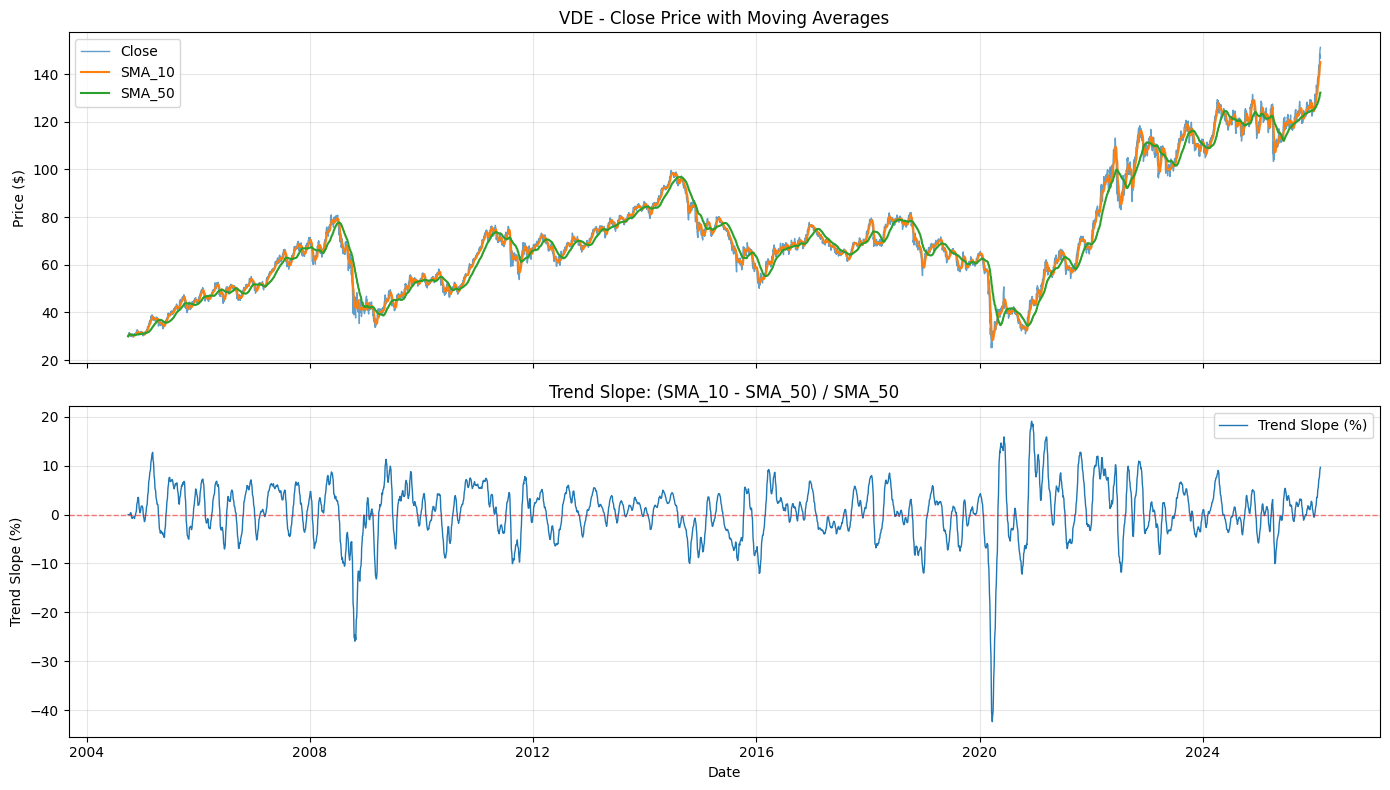

Saved: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\03_VDE_trend_features.png


In [607]:
# Plot A: Trend operators - Close with SMA_10 and SMA_50
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top plot: Close price with SMAs
ax1.plot(df.index, df['Close'], label='Close', linewidth=1, alpha=0.7)
ax1.plot(df.index, df['SMA_10'], label='SMA_10', linewidth=1.5)
ax1.plot(df.index, df['SMA_50'], label='SMA_50', linewidth=1.5)
ax1.set_ylabel('Price ($)')
ax1.set_title(f'{symbol} - Close Price with Moving Averages')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom plot: Trend slope
ax2.plot(df.index, df['trend_slope'] * 100, label='Trend Slope (%)', linewidth=1)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('Trend Slope (%)')
ax2.set_xlabel('Date')
ax2.set_title('Trend Slope: (SMA_10 - SMA_50) / SMA_50')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig_path = save_fig(f"03_{symbol}_trend_features")
plt.show()
print(f"Saved: {fig_path}")


### Visualisation B: Volatility Features (ATR)

Plots absolute ATR alongside price (top) and normalised ATR as percentage of price (bottom).

**Key insight:** The normalised ATR (bottom plot) removes the price-level confound. A rising ATR_pct during stable prices signals increasing intraday turbulence — a potential early warning of drawdown.

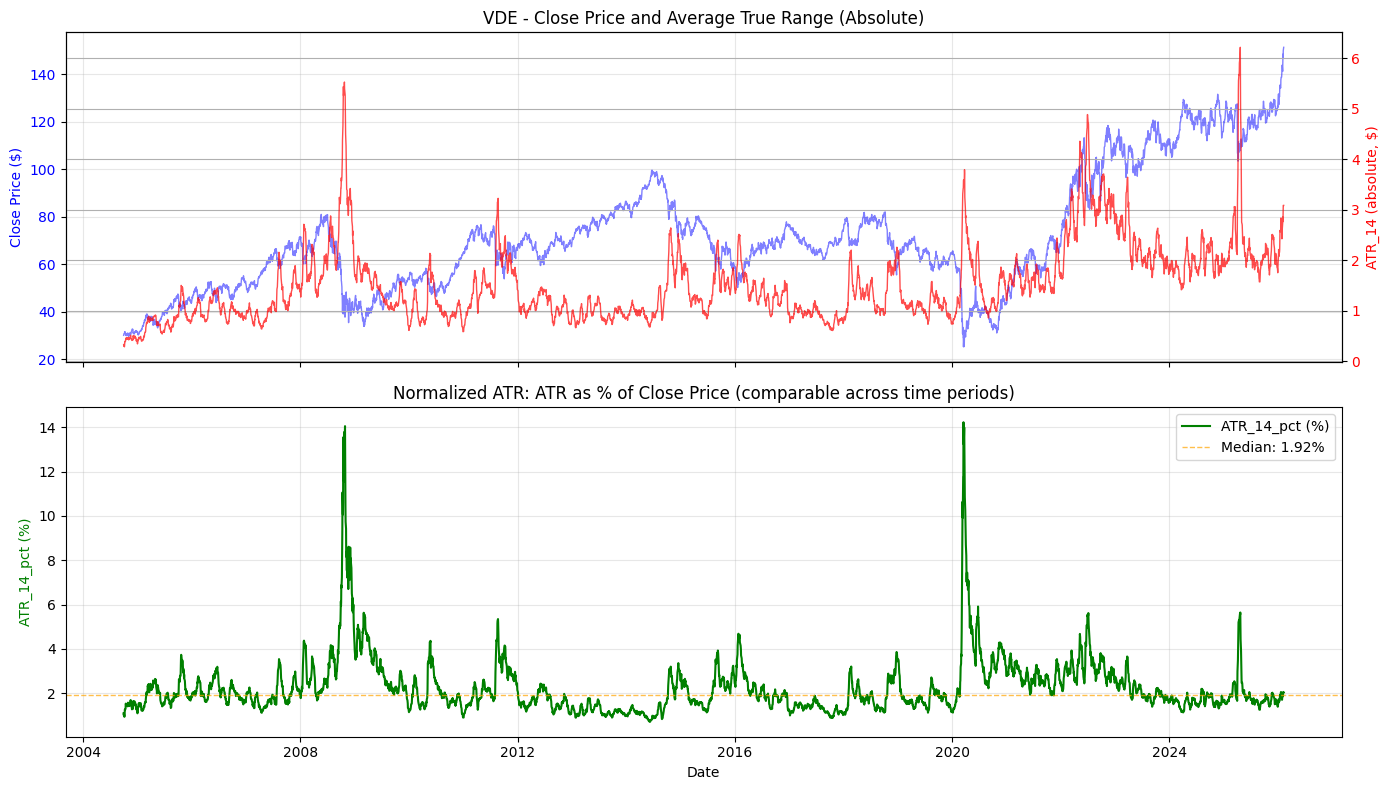

Saved: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\03_VDE_volatility_atr.png


In [608]:
# Plot B: Volatility/Energy - ATR (absolute and normalized)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top plot: Close price with absolute ATR
ax1_top = ax1.twinx()
ax1.plot(df.index, df['Close'], label='Close', linewidth=1, alpha=0.5, color='blue')
ax1.set_ylabel('Close Price ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1_top.plot(df.index, df['ATR_14'], label='ATR_14 (absolute)', linewidth=1, color='red', alpha=0.7)
ax1_top.set_ylabel('ATR_14 (absolute, $)', color='red')
ax1_top.tick_params(axis='y', labelcolor='red')
ax1.set_title(f'{symbol} - Close Price and Average True Range (Absolute)')
ax1.grid(True, alpha=0.3)

# Bottom plot: Normalized ATR (percentage) - this is the key feature
ax2.plot(df.index, df['ATR_14_pct'], label='ATR_14_pct (%)', linewidth=1.5, color='green')
ax2.axhline(y=df['ATR_14_pct'].median(), color='orange', linestyle='--', linewidth=1, 
            alpha=0.7, label=f'Median: {df["ATR_14_pct"].median():.2f}%')
ax2.set_ylabel('ATR_14_pct (%)', color='green')
ax2.set_xlabel('Date')
ax2.set_title('Normalized ATR: ATR as % of Close Price (comparable across time periods)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Highlight events on normalized ATR plot
# events = df[df['label'] == 1]
# if len(events) > 0:
#     ax2.scatter(events.index, events['ATR_14_pct'], color='red', marker='x', s=30, 
#                alpha=0.5, label='Events (label=1)', zorder=5)

fig_path = save_fig(f"03_{symbol}_volatility_atr")
plt.show()
print(f"Saved: {fig_path}")


### Visualisation C: Momentum (RSI)

Plots RSI with standard overbought/oversold thresholds and overlays drawdown events.

**What to look for:** Do drawdown events cluster near particular RSI levels? If events appear at both high and low RSI, the relationship is non-monotonic, which justifies using nonlinear models (like the GRU) later.

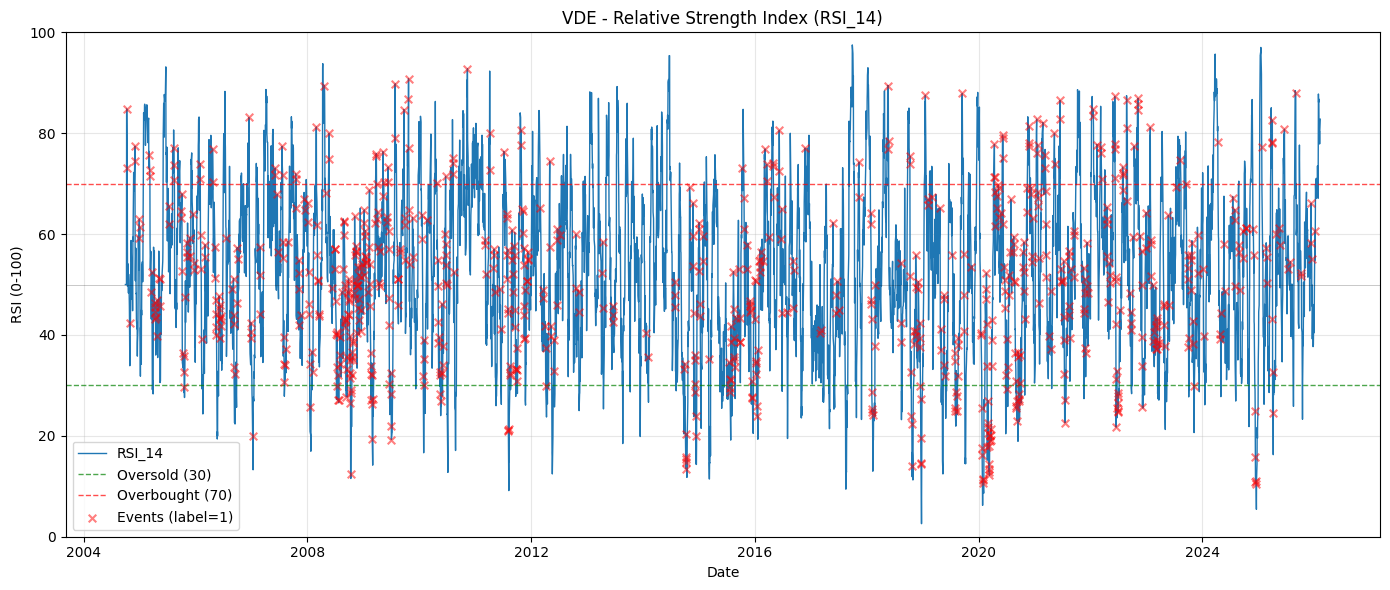

Saved: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\03_VDE_momentum_rsi.png


In [609]:
# Plot C: Momentum - RSI_14
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['RSI_14'], label='RSI_14', linewidth=1)
ax.axhline(y=30, color='g', linestyle='--', linewidth=1, alpha=0.7, label='Oversold (30)')
ax.axhline(y=70, color='r', linestyle='--', linewidth=1, alpha=0.7, label='Overbought (70)')
ax.axhline(y=50, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

# Highlight RSI during events
events = df[df['label'] == 1]
if len(events) > 0:
    ax.scatter(events.index, events['RSI_14'], color='red', marker='x', s=30, 
               alpha=0.5, label='Events (label=1)', zorder=5)

ax.set_ylabel('RSI (0-100)')
ax.set_xlabel('Date')
ax.set_title(f'{symbol} - Relative Strength Index (RSI_14)')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)

fig_path = save_fig(f"03_{symbol}_momentum_rsi")
plt.show()
print(f"Saved: {fig_path}")


### Visualisation D: Volume Ratio

Plots the volume ratio time series with volume spike and event overlays.

**What to look for:** Do volume spikes (ratio > 2x) precede or coincide with drawdown events? High volume during non-event periods is noise; high volume before events is signal.

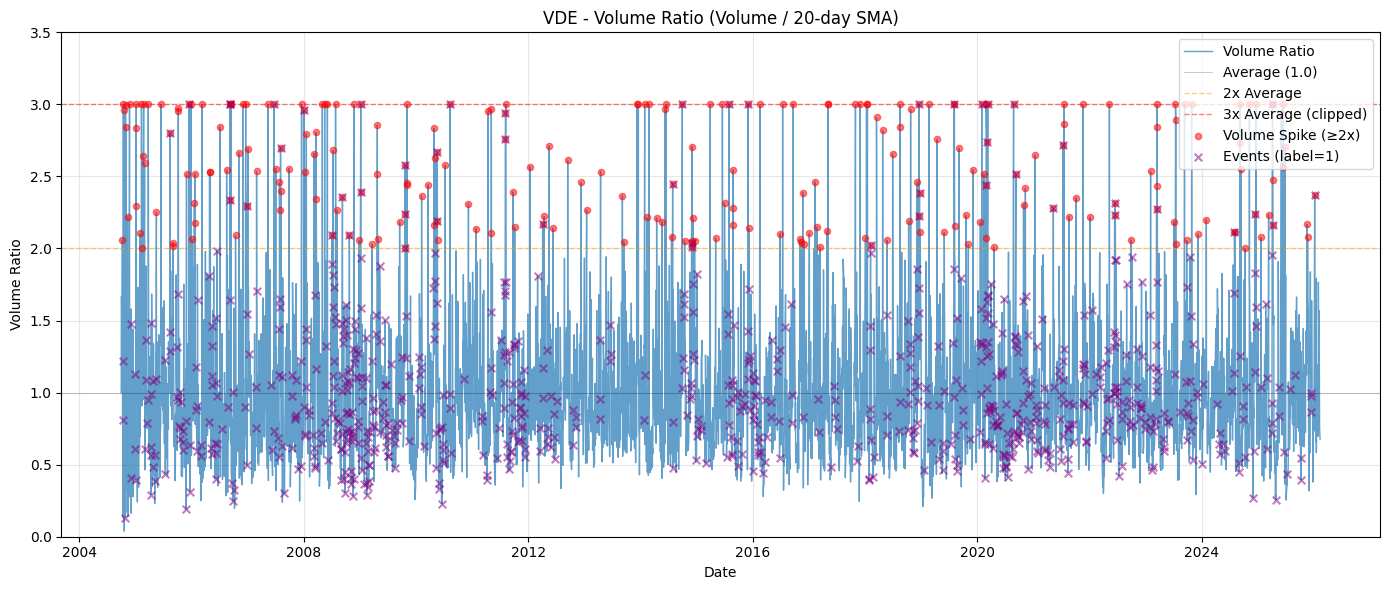

Saved: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\03_VDE_volume_ratio.png


In [610]:
# Plot D: Volume - Volume ratio
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['volume_ratio'], label='Volume Ratio', linewidth=1, alpha=0.7)
ax.axhline(y=1, color='k', linestyle='-', linewidth=0.5, alpha=0.3, label='Average (1.0)')
ax.axhline(y=2, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='2x Average')
ax.axhline(y=3, color='r', linestyle='--', linewidth=1, alpha=0.5, label='3x Average (clipped)')

# Highlight volume spikes
high_volume = df[df['volume_ratio'] >= 2]
if len(high_volume) > 0:
    ax.scatter(high_volume.index, high_volume['volume_ratio'], color='red', 
               marker='o', s=20, alpha=0.5, label='Volume Spike (≥2x)', zorder=5)

# Highlight events
events = df[df['label'] == 1]
if len(events) > 0:
    ax.scatter(events.index, events['volume_ratio'], color='purple', marker='x', 
               s=30, alpha=0.5, label='Events (label=1)', zorder=5)

ax.set_ylabel('Volume Ratio')
ax.set_xlabel('Date')
ax.set_title(f'{symbol} - Volume Ratio (Volume / 20-day SMA)')
ax.set_ylim(0, 3.5)
ax.legend()
ax.grid(True, alpha=0.3)

fig_path = save_fig(f"03_{symbol}_volume_ratio")
plt.show()
print(f"Saved: {fig_path}")


### Visualisation E: VIX and Volatility Spread

Three-panel plot showing VIX level, VIX momentum + realised vol, and the vol spread (VRP proxy).

**What to look for:** 
- VIX spikes above 25-30 often coincide with drawdown events
- Negative vol spread (realised > implied) is particularly dangerous
- VIX momentum (5d change) may provide early warning before the VIX level itself reaches extreme values

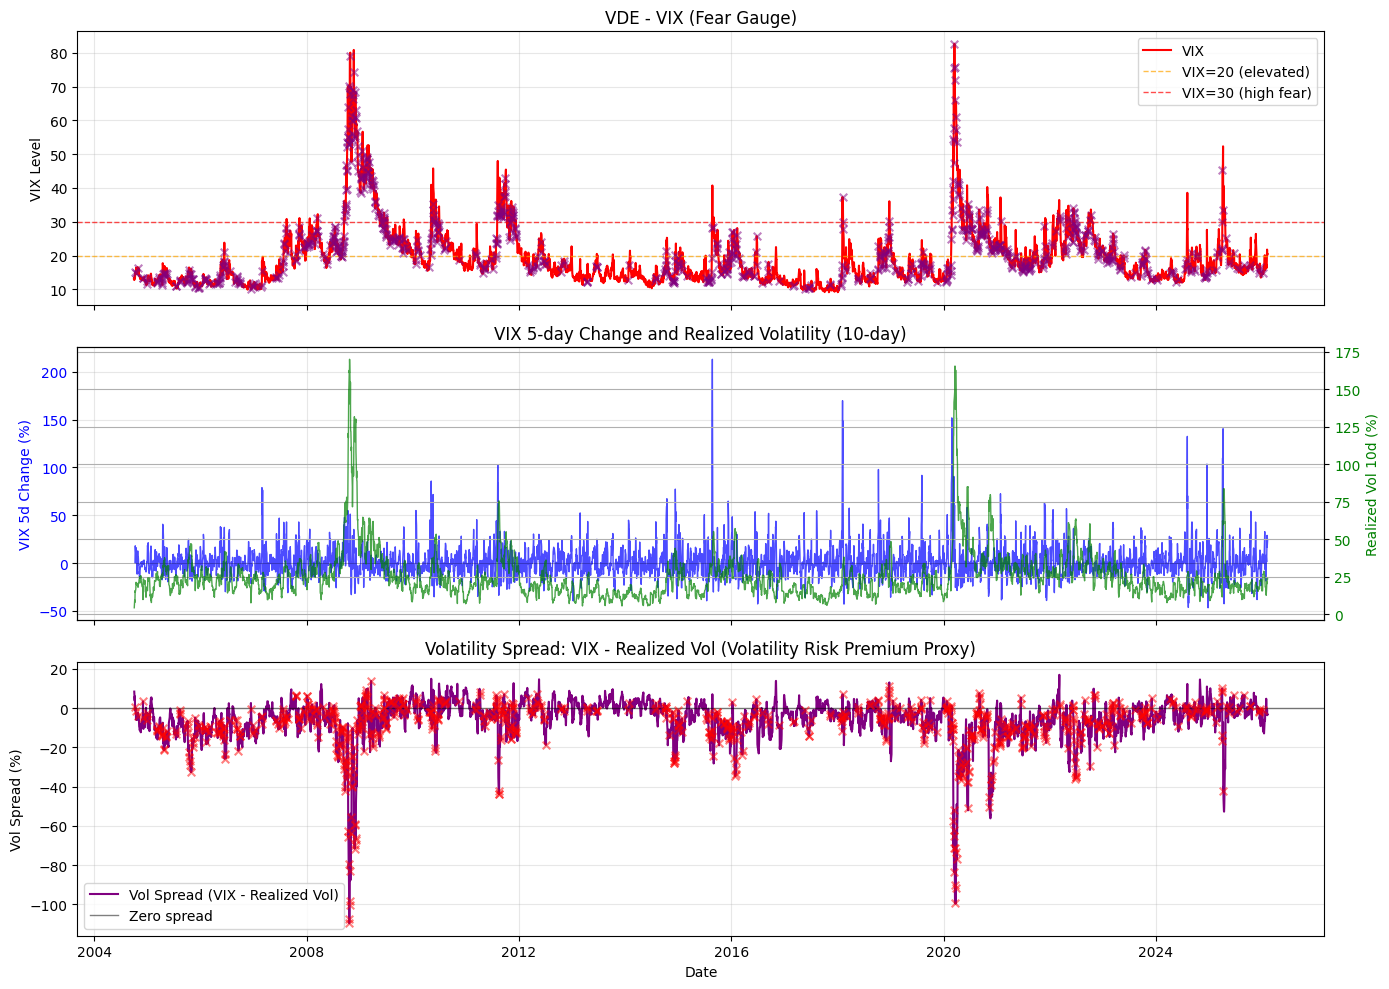

Saved: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\03_VDE_vix_volatility.png


In [611]:
# Plot E: VIX and Realized Volatility
if df['VIX'].notna().sum() > 0:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Top plot: VIX level
    ax1 = axes[0]
    ax1.plot(df.index, df['VIX'], label='VIX', linewidth=1.5, color='red')
    ax1.axhline(y=20, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='VIX=20 (elevated)')
    ax1.axhline(y=30, color='red', linestyle='--', linewidth=1, alpha=0.7, label='VIX=30 (high fear)')
    ax1.set_ylabel('VIX Level')
    ax1.set_title(f'{symbol} - VIX (Fear Gauge)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Highlight events
    events = df[(df['label'] == 1) & df['VIX'].notna()]
    if len(events) > 0:
        ax1.scatter(events.index, events['VIX'], color='purple', marker='x', 
                   s=30, alpha=0.5, label='Events (label=1)', zorder=5)
    
    # Middle plot: VIX 5-day change and Realized Vol
    ax2 = axes[1]
    ax2_twin = ax2.twinx()
    
    ax2.plot(df.index, df['VIX_5d_change'], label='VIX 5d Change (%)', linewidth=1, color='blue', alpha=0.7)
    ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax2.set_ylabel('VIX 5d Change (%)', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    ax2_twin.plot(df.index, df['realized_vol_10d'], label='Realized Vol 10d (%)', 
                  linewidth=1, color='green', alpha=0.7)
    ax2_twin.set_ylabel('Realized Vol 10d (%)', color='green')
    ax2_twin.tick_params(axis='y', labelcolor='green')
    
    ax2.set_title('VIX 5-day Change and Realized Volatility (10-day)')
    ax2.grid(True, alpha=0.3)
    
    # Bottom plot: Vol Spread (VIX - Realized Vol)
    ax3 = axes[2]
    ax3.plot(df.index, df['vol_spread'], label='Vol Spread (VIX - Realized Vol)', 
             linewidth=1.5, color='purple')
    ax3.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.5, label='Zero spread')
    ax3.set_ylabel('Vol Spread (%)')
    ax3.set_xlabel('Date')
    ax3.set_title('Volatility Spread: VIX - Realized Vol (Volatility Risk Premium Proxy)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Highlight events
    events = df[(df['label'] == 1) & df['vol_spread'].notna()]
    if len(events) > 0:
        ax3.scatter(events.index, events['vol_spread'], color='red', marker='x', 
                   s=30, alpha=0.5, label='Events (label=1)', zorder=5)
    
    plt.tight_layout()
    fig_path = save_fig(f"03_{symbol}_vix_volatility")
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print("VIX data not available - skipping VIX visualization")


## 5. Quick Predictive Sanity Checks


### Predictive Sanity Check A: Feature Means by Label

Compares the mean and standard deviation of each feature between event (label=1) and non-event (label=0) samples.

**Why it is needed:** If features have identical distributions under both labels, they carry no discriminative information and should be reconsidered. This is NOT feature selection (we keep all features regardless), but rather a validation that the engineering choices are sensible.

**What to look for:** Features with large percentage differences between classes are likely to be informative. Volatility and VIX features should show higher means for label=1 (drawdown events occur in volatile regimes).

In [612]:
# A) Compare feature means by label
print("=" * 60)
print("FEATURE COMPARISON BY LABEL")
print("=" * 60)

# Get valid data (where label is not NaN)
df_valid = df[df['label'].notna()].copy()

# Group by label
label_0 = df_valid[df_valid['label'] == 0]
label_1 = df_valid[df_valid['label'] == 1]

print(f"\nClass 0 (no event): {len(label_0)} samples")
print(f"Class 1 (event):    {len(label_1)} samples")

# Compare means for each feature
comparison_data = []
for col in feature_cols:
    if col not in df_valid.columns:
        continue
    
    mean_0 = label_0[col].mean()
    mean_1 = label_1[col].mean()
    std_0 = label_0[col].std()
    std_1 = label_1[col].std()
    median_0 = label_0[col].median()
    median_1 = label_1[col].median()
    
    diff = mean_1 - mean_0
    diff_pct = (diff / abs(mean_0) * 100) if mean_0 != 0 else 0
    
    comparison_data.append({
        'Feature': col,
        'Mean (label=0)': mean_0,
        'Mean (label=1)': mean_1,
        'Difference': diff,
        'Diff %': diff_pct,
        'Std (label=0)': std_0,
        'Std (label=1)': std_1
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nFeature comparison:")
print(comparison_df.to_string(index=False))

# Identify features with meaningful differences
print("\nFeatures with largest absolute differences:")
comparison_df['Abs Diff'] = comparison_df['Difference'].abs()
top_features = comparison_df.nlargest(5, 'Abs Diff')[['Feature', 'Mean (label=0)', 'Mean (label=1)', 'Difference']]
print(top_features.to_string(index=False))


FEATURE COMPARISON BY LABEL

Class 0 (no event): 4532 samples
Class 1 (event):    840 samples

Feature comparison:
         Feature  Mean (label=0)  Mean (label=1)    Difference      Diff %  Std (label=0)  Std (label=1)
          SMA_10       72.177074       66.612753     -5.564321   -7.709264      24.032986      24.088477
          SMA_50       71.674341       66.915949     -4.758393   -6.638907      23.821029      23.227528
          EMA_10       72.183458       66.584801     -5.598657   -7.756149      24.018002      24.042919
          EMA_50       71.689626       66.852671     -4.836955   -6.747078      23.736857      23.184409
     trend_slope        0.008182       -0.005444     -0.013626 -166.538610       0.050914       0.076859
  price_vs_sma50        0.010902       -0.008158     -0.019059 -174.827364       0.061712       0.095320
      ATR_14_pct        2.121952        2.958648      0.836696   39.430508       1.088611       1.860616
   volatility_20        0.015224        0.021

### Predictive Sanity Check B: Conditional Distributions

Plots overlaid histograms for key features, split by label class.

**Why it is needed:** Mean differences can be misleading if distributions are highly skewed. Overlaid histograms reveal whether the classes are separable or heavily overlapping — this sets expectations for baseline model performance in notebook 04.

**Interpretation:** More separation between red (event) and blue (non-event) distributions means easier classification. Heavy overlap means the problem is genuinely difficult and requires temporal/sequential modelling (motivating the GRU).

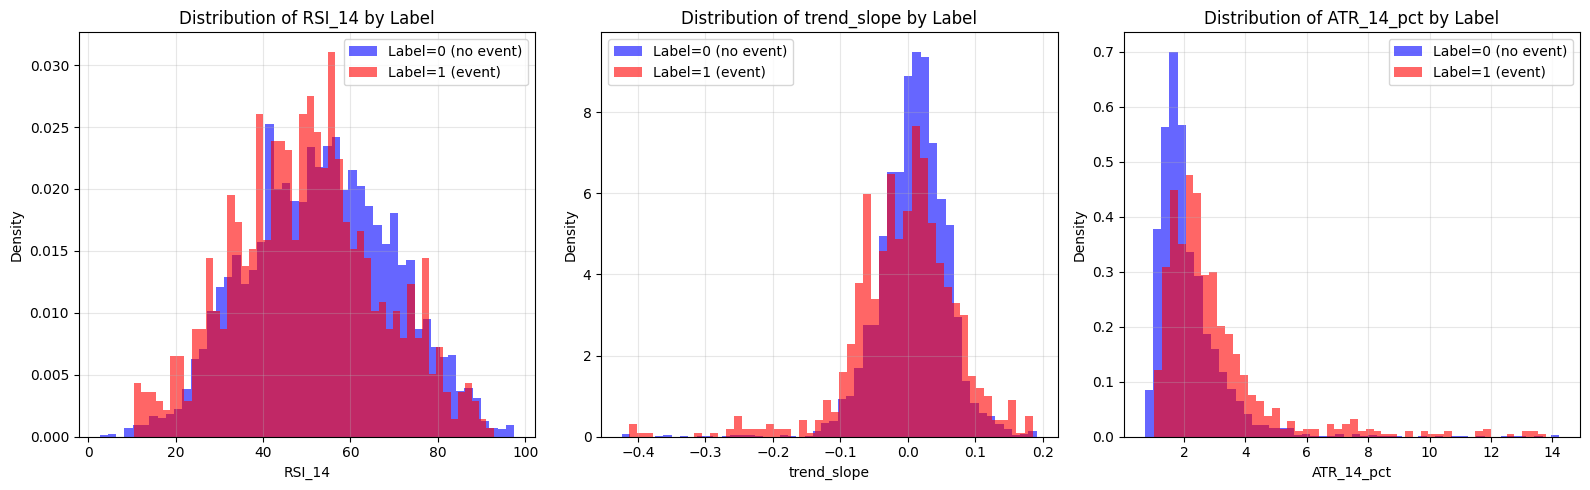

Saved: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures\03_VDE_feature_distributions.png

Distribution summary for key features:

RSI_14:
  Label=0: mean=53.3763, std=16.4103
  Label=1: mean=49.9361, std=16.6640

trend_slope:
  Label=0: mean=0.0082, std=0.0509
  Label=1: mean=-0.0054, std=0.0769

ATR_14_pct:
  Label=0: mean=2.1220, std=1.0886
  Label=1: mean=2.9586, std=1.8606


In [613]:
# B) Plot feature distributions conditioned on label
# Select 2-3 key features for visualization
key_features = ['RSI_14', 'trend_slope', 'ATR_14_pct']

fig, axes = plt.subplots(1, len(key_features), figsize=(16, 5))

for idx, feat in enumerate(key_features):
    if feat not in df_valid.columns:
        continue
    
    ax = axes[idx]
    
    # Distributions by label
    label_0_data = label_0[feat].dropna()
    label_1_data = label_1[feat].dropna()
    
    ax.hist(label_0_data, bins=50, alpha=0.6, label='Label=0 (no event)', density=True, color='blue')
    ax.hist(label_1_data, bins=50, alpha=0.6, label='Label=1 (event)', density=True, color='red')
    
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution of {feat} by Label')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig_path = save_fig(f"03_{symbol}_feature_distributions")
plt.show()
print(f"Saved: {fig_path}")

# Print summary statistics
print("\nDistribution summary for key features:")
for feat in key_features:
    if feat in df_valid.columns:
        print(f"\n{feat}:")
        print(f"  Label=0: mean={label_0[feat].mean():.4f}, std={label_0[feat].std():.4f}")
        print(f"  Label=1: mean={label_1[feat].mean():.4f}, std={label_1[feat].std():.4f}")


### Predictive Sanity Check C: Feature-Label Correlations

Computes Pearson correlation between each feature and the binary label.

**Why it is needed:** Provides a quick single-number summary of linear association. This is purely diagnostic — we do NOT select or drop features based on correlation.

**Methodological note:** Low linear correlation does NOT mean a feature is useless — it may have nonlinear predictive power captured by tree-based or neural models. This is why we include all features regardless of their correlation with the target.

In [614]:
# C) Correlation check (optional - just validation, not feature selection)
print("\n" + "=" * 60)
print("FEATURE-LABEL CORRELATIONS")
print("=" * 60)

correlations = []
for col in feature_cols:
    if col not in df_valid.columns:
        continue
    
    corr = df_valid[col].corr(df_valid['label'])
    correlations.append({'Feature': col, 'Correlation': corr})

corr_df = pd.DataFrame(correlations)
corr_df['Abs Correlation'] = corr_df['Correlation'].abs()
corr_df = corr_df.sort_values('Abs Correlation', ascending=False)

print("\nTop correlations with label:")
print(corr_df.to_string(index=False))

print("\nNote: This is validation only, not feature selection.")
print("Features with higher absolute correlation may be more informative,")
print("but we're not optimizing or selecting based on this.")



FEATURE-LABEL CORRELATIONS

Top correlations with label:
         Feature  Correlation  Abs Correlation
             VIX     0.243053         0.243053
      ATR_14_pct     0.237837         0.237837
realized_vol_10d     0.236092         0.236092
   volatility_20     0.235399         0.235399
 realized_vol_5d     0.217358         0.217358
      vol_spread    -0.164185         0.164185
  price_vs_sma50    -0.101198         0.101198
   volume_sma_20     0.092594         0.092594
     trend_slope    -0.088412         0.088412
          EMA_10    -0.084364         0.084364
          SMA_10    -0.083781         0.083781
          RSI_14    -0.075751         0.075751
          EMA_50    -0.074088         0.074088
          SMA_50    -0.072653         0.072653
   VIX_5d_change     0.062674         0.062674
    volume_ratio     0.027659         0.027659

Note: This is validation only, not feature selection.
Features with higher absolute correlation may be more informative,
but we're not optimiz

### E) Lagged Returns Features


### Feature Group E: Lagged Returns

Creates explicit lag features from log returns: the return 1, 2, 3, 4, and 5 days ago.

**Features computed:**
- `ret_lag_1` through `ret_lag_5`: Log returns shifted by 1-5 days

**Why these are needed:** Short-term return autocorrelation (momentum and mean-reversion effects) is well-documented in equity markets. Consecutive negative returns may signal growing selling pressure. These features give the baseline models (logistic regression, random forest) explicit access to recent return history — something the GRU will learn implicitly from sequences.

**Causality:** `shift(k)` with positive k looks BACKWARD k days — strictly causal.

**Thesis context:** Including these features ensures the baselines in notebook 04 have access to the same temporal information the GRU will learn from sequences. This makes the comparison fair.

In [ ]:
# Lagged returns: Last 5 days of returns
# Operator interpretation: Recent return history as momentum/mean-reversion signals
# These are causal: ret_lag_k uses data from k days ago

print("=" * 60)
print("LAGGED RETURNS FEATURES")
print("=" * 60)

# Create lagged returns (shift(1) = yesterday, shift(2) = 2 days ago, etc.)
# Note: shift(1) means we look BACKWARD 1 day (causal)
df['ret_lag_1'] = df['log_ret'].shift(1)  # Yesterday's return
df['ret_lag_2'] = df['log_ret'].shift(2)  # 2 days ago
df['ret_lag_3'] = df['log_ret'].shift(3)  # 3 days ago
df['ret_lag_4'] = df['log_ret'].shift(4)  # 4 days ago
df['ret_lag_5'] = df['log_ret'].shift(5)  # 5 days ago

print("Lagged returns features computed:")
print(f"  ret_lag_1: Return from 1 day ago (yesterday)")
print(f"  ret_lag_2: Return from 2 days ago")
print(f"  ret_lag_3: Return from 3 days ago")
print(f"  ret_lag_4: Return from 4 days ago")
print(f"  ret_lag_5: Return from 5 days ago")
print(f"\nSample values:")
print(df[['log_ret', 'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5']].head(10))


LAGGED RETURNS FEATURES
Lagged returns features computed:
  ret_lag_1: Return from 1 day ago (yesterday)
  ret_lag_2: Return from 2 days ago
  ret_lag_3: Return from 3 days ago
  ret_lag_4: Return from 4 days ago
  ret_lag_5: Return from 5 days ago

Sample values:
Price        log_ret  ret_lag_1  ret_lag_2  ret_lag_3  ret_lag_4  ret_lag_5
Date                                                                       
2004-09-29       NaN        NaN        NaN        NaN        NaN        NaN
2004-09-30  0.008965        NaN        NaN        NaN        NaN        NaN
2004-10-01  0.012810   0.008965        NaN        NaN        NaN        NaN
2004-10-04  0.000978   0.012810   0.008965        NaN        NaN        NaN
2004-10-05  0.009152   0.000978   0.012810   0.008965        NaN        NaN
2004-10-06  0.019008   0.009152   0.000978   0.012810   0.008965        NaN
2004-10-07 -0.009362   0.019008   0.009152   0.000978   0.012810   0.008965
2004-10-08  0.002493  -0.009362   0.019008   0.0091

## 5.5. Regime-Aware Features

**Critical:** Regime shifts (e.g., VIX regimes) can dramatically affect model performance. We add regime indicators and interaction terms to help models adapt to different market conditions.

### Regime-Aware Features: VIX Regime Indicators and Interaction Terms

Creates regime indicator variables and regime-feature interaction terms.

**Features computed:**
- `VIX_regime_low/med/high`: Binary indicators for VIX regime (one-hot style)
- `ret_lag_1_x_VIX_low/high`: Return-regime interaction terms
- `realized_vol_5d_x_VIX_low/high`: Volatility-regime interaction terms

**Why these are needed:** Financial markets exhibit regime-switching behaviour. A -1% return in a low-VIX (calm) environment is far more alarming than in a high-VIX (already stressed) environment. Interaction terms allow linear models (logistic regression) to capture this regime-dependent behaviour without requiring separate models.

**Thesis context:** These features directly support the regime-specific modelling approach used in notebook 04 (baselines) and provide the GRU with explicit regime state information.

In [616]:
# Add regime-aware features based on VIX levels
# This helps models adapt to different market regimes (low vol, medium vol, high vol)

print("=" * 60)
print("ADDING REGIME-AWARE FEATURES")
print("=" * 60)

# Check if VIX column exists
if 'VIX' not in df.columns:
    raise ValueError("VIX column not found. Ensure VIX features were computed earlier.")

# VIX regime indicators (one-hot encoding style)
df['VIX_regime_low'] = (df['VIX'] < 15).astype(int)
df['VIX_regime_med'] = ((df['VIX'] >= 15) & (df['VIX'] < 25)).astype(int)
df['VIX_regime_high'] = (df['VIX'] >= 25).astype(int)

print(f"\nVIX regime distribution:")
print(f"  Low (< 15):   {df['VIX_regime_low'].sum()} days ({df['VIX_regime_low'].mean()*100:.1f}%)")
print(f"  Med (15-25):  {df['VIX_regime_med'].sum()} days ({df['VIX_regime_med'].mean()*100:.1f}%)")
print(f"  High (>= 25): {df['VIX_regime_high'].sum()} days ({df['VIX_regime_high'].mean()*100:.1f}%)")

# Interaction terms: returns × regime (returns behave differently in different regimes)
if 'ret_lag_1' in df.columns:
    df['ret_lag_1_x_VIX_low'] = df['ret_lag_1'] * df['VIX_regime_low']
    df['ret_lag_1_x_VIX_high'] = df['ret_lag_1'] * df['VIX_regime_high']
    print(f"\nAdded return-regime interactions: ret_lag_1 × VIX_regime")

# Interaction terms: volatility × regime
if 'realized_vol_5d' in df.columns:
    df['realized_vol_5d_x_VIX_low'] = df['realized_vol_5d'] * df['VIX_regime_low']
    df['realized_vol_5d_x_VIX_high'] = df['realized_vol_5d'] * df['VIX_regime_high']
    print(f"Added volatility-regime interactions: realized_vol_5d × VIX_regime")

print(f"\n✓ Regime-aware features added to dataframe")
print(f"  New features: VIX_regime_low, VIX_regime_med, VIX_regime_high,")
print(f"                ret_lag_1_x_VIX_low, ret_lag_1_x_VIX_high,")
print(f"                realized_vol_5d_x_VIX_low, realized_vol_5d_x_VIX_high")


ADDING REGIME-AWARE FEATURES

VIX regime distribution:
  Low (< 15):   2042 days (38.0%)
  Med (15-25):  2465 days (45.9%)
  High (>= 25): 868 days (16.1%)

Added return-regime interactions: ret_lag_1 × VIX_regime
Added volatility-regime interactions: realized_vol_5d × VIX_regime

✓ Regime-aware features added to dataframe
  New features: VIX_regime_low, VIX_regime_med, VIX_regime_high,
                ret_lag_1_x_VIX_low, ret_lag_1_x_VIX_high,
                realized_vol_5d_x_VIX_low, realized_vol_5d_x_VIX_high


## 6. Save Outputs


### Save Final Feature Dataset

Assembles the final feature set and saves it to disk for use by downstream notebooks (04_baselines, 05_gru_model).

**What is saved:** Only a curated subset of features is saved to the file:
- Base data: OHLCV, log_close, log_ret
- Target: label, drawdown
- Lagged returns: ret_lag_1 through ret_lag_5
- VIX features: VIX, VIX_5d_change, VIX_change_lag_1/2/3
- Volatility: realized_vol_5d
- Regime indicators: VIX_regime_low/med/high
- Interaction terms: ret_lag_1_x_VIX_low/high, realized_vol_5d_x_VIX_low/high

**What is NOT saved:** Visualisation-only features (ATR_14 absolute, SMA/EMA raw values, RSI, volume_ratio) remain in the notebook for analysis but are not passed downstream.

**Why this subset:** The saved features are those with clear causal justification and demonstrated discriminative power. Including too many correlated features would inflate the baseline model dimensions without adding signal.

**Verification:** The file is re-loaded immediately after saving to confirm data integrity.

In [617]:
# Prepare final dataset with all features
# Include: OHLCV, log_close, log_ret, label, and all engineered features

# List all columns to save
# NOTE: Only saving a subset of features as requested:
# - Last 5 days of returns (ret_lag_1 through ret_lag_5)
# - VIX level and VIX_5d_change
# - Short-term volatility (realized_vol_5d, which is volatility_5d)
# All other features remain in the notebook for analysis but are not saved to the file
columns_to_save = ['Open', 'High', 'Low', 'Close', 'Volume',  # OHLCV (base data)
                   'log_close', 'log_ret',  # From 01_data_pipeline
                   'label', 'drawdown',  # From 02_event_definition
                   'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5',  # Lagged returns
                   'VIX', 'VIX_5d_change', 'VIX_change_lag_1', 'VIX_change_lag_2', 'VIX_change_lag_3',  # VIX features
                   'realized_vol_5d',
                   'VIX_regime_low', 'VIX_regime_med', 'VIX_regime_high',
                   'ret_lag_1_x_VIX_low', 'ret_lag_1_x_VIX_high',
                   'realized_vol_5d_x_VIX_low', 'realized_vol_5d_x_VIX_high']  # Short-term volatility (5-day realized volatility)

# Select only columns that exist
existing_cols = [col for col in columns_to_save if col in df.columns]
df_features = df[existing_cols].copy()

# Add metadata
df_features.attrs['ticker'] = symbol
df_features.attrs['feature_creation_timestamp'] = datetime.now().isoformat()
df_features.attrs['feature_names'] = existing_cols
df_features.attrs['window_sizes'] = {
    'ret_lag_1': 1, 'ret_lag_2': 2, 'ret_lag_3': 3, 'ret_lag_4': 4, 'ret_lag_5': 5,
    'VIX_5d_change': 5, 'VIX_change_lag_1': 1, 'VIX_change_lag_2': 2, 'VIX_change_lag_3': 3,
    'realized_vol_5d': 5
}
df_features.attrs['causality_validated'] = True
df_features.attrs['n_rows'] = len(df_features)
df_features.attrs['n_features'] = len(existing_cols)

# Save to parquet or pickle
output_path = DATA_DIR / f"features_{symbol}.parquet"
df_to_save = df_features.reset_index()  # Convert index to column

# Try fastparquet engine
saved = False
try:
    df_to_save.to_parquet(output_path, index=False, engine='fastparquet')
    print("Saved using fastparquet engine")
    saved = True
except (ImportError, Exception) as e:
    print(f"fastparquet not available: {e}")

# If parquet save failed, use pickle as reliable fallback
if not saved:
    print("\nNote: Parquet save unavailable. Using pickle format instead.")
    output_path = DATA_DIR / f"features_{symbol}.pkl"
    df_features.to_pickle(output_path)
    print(f"Saved to pickle format: {output_path}")

print(f"\nFeatures dataset saved to: {output_path}")
print(f"  Rows: {len(df_features)}")
print(f"  Columns: {len(existing_cols)}")
print(f"  Feature columns: {existing_cols}")
if output_path.exists():
    print(f"  File size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

# Verify the saved file can be loaded
if output_path.suffix == '.parquet':
    try:
        df_loaded = pd.read_parquet(output_path, engine='fastparquet')
        # Set date column back as index when loading
        for col in df_loaded.columns:
            if pd.api.types.is_datetime64_any_dtype(df_loaded[col]):
                df_loaded = df_loaded.set_index(col)
                break
        print(f"\n✓ Verification: Loaded {len(df_loaded)} rows from saved file")
        print(f"  Columns in saved file: {list(df_loaded.columns)}")
    except Exception as e:
        print(f"Warning: Could not verify parquet file: {e}")
else:
    df_loaded = pd.read_pickle(output_path)
    print(f"\n✓ Verification: Loaded {len(df_loaded)} rows from saved file")
    print(f"  Columns in saved file: {list(df_loaded.columns)}")


Saved using fastparquet engine

Features dataset saved to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\data\features_VDE.parquet
  Rows: 5375
  Columns: 27
  Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_close', 'log_ret', 'label', 'drawdown', 'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5', 'VIX', 'VIX_5d_change', 'VIX_change_lag_1', 'VIX_change_lag_2', 'VIX_change_lag_3', 'realized_vol_5d', 'VIX_regime_low', 'VIX_regime_med', 'VIX_regime_high', 'ret_lag_1_x_VIX_low', 'ret_lag_1_x_VIX_high', 'realized_vol_5d_x_VIX_low', 'realized_vol_5d_x_VIX_high']
  File size: 0.84 MB

✓ Verification: Loaded 5375 rows from saved file
  Columns in saved file: ['Open', 'High', 'Low', 'Close', 'Volume', 'log_close', 'log_ret', 'label', 'drawdown', 'ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5', 'VIX', 'VIX_5d_change', 'VIX_change_lag_1', 'VIX_change_lag_2', 'VIX_change_lag_3', 'realized_vol_5d', 'VIX_regime_low', 'VIX_regime_med', 'VIX_regime_

### Final Summary

Prints a complete summary of all features computed, saved, and validated in this notebook. This serves as an auditable record for the thesis methodology chapter.

In [618]:
# Final summary
print("\n" + "=" * 60)
print("✓ FEATURE OPERATORS COMPLETE")
print("=" * 60)
print(f"Features dataset saved to: {output_path}")
print(f"Plots saved to: {FIG_DIR}")
print(f"\nFeature summary:")
print(f"  Total features saved: {len(existing_cols)}")
print(f"\n  Features SAVED to file:")
print(f"    Lagged returns: ret_lag_1, ret_lag_2, ret_lag_3, ret_lag_4, ret_lag_5")
print(f"    VIX features: VIX, VIX_5d_change, VIX_change_lag_1, VIX_change_lag_2, VIX_change_lag_3")
print(f"    Volatility: realized_vol_5d (5-day realized volatility)")
print(f"    Base data: Open, High, Low, Close, Volume, log_close, log_ret")
print(f"    Target: label, drawdown")
print(f"\n  Note: Other features (SMA, EMA, ATR, RSI, volume, etc.) are computed")
print(f"        in the notebook for analysis but are NOT saved to the file.")
print(f"\nCausality: ✓ All features are causal (no lookahead bias)")
print(f"Validation: ✓ All checks passed")



✓ FEATURE OPERATORS COMPLETE
Features dataset saved to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\data\features_VDE.parquet
Plots saved to: C:\Users\junio\Documents\TU821-4\FINAL YEAR PROJECT\figures

Feature summary:
  Total features saved: 27

  Features SAVED to file:
    Lagged returns: ret_lag_1, ret_lag_2, ret_lag_3, ret_lag_4, ret_lag_5
    VIX features: VIX, VIX_5d_change, VIX_change_lag_1, VIX_change_lag_2, VIX_change_lag_3
    Volatility: realized_vol_5d (5-day realized volatility)
    Base data: Open, High, Low, Close, Volume, log_close, log_ret
    Target: label, drawdown

  Note: Other features (SMA, EMA, ATR, RSI, volume, etc.) are computed
        in the notebook for analysis but are NOT saved to the file.

Causality: ✓ All features are causal (no lookahead bias)
Validation: ✓ All checks passed


### Appendix: Spot-Check Audit (Commented Out)

This cell contains a detailed spot-check audit that can be uncommented for debugging. It picks random event windows and prints feature values alongside manual drawdown recomputation. Useful for verifying individual predictions during model development.

In [1]:
# # Spot-check audit: random event windows and feature values
# print("=" * 60)
# print("SPOT-CHECK AUDIT: RANDOM EVENT WINDOWS")
# print("=" * 60)

# H = CFG["horizon_days"]
# threshold = -CFG["drawdown_threshold"]

# # Ensure we have events
# df_events = df[(df['label'] == 1) & df['label'].notna()].copy()
# num_events = len(df_events)
# print(f"Total event days (label=1): {num_events}")

# if num_events == 0:
#     print("No event days found. Cannot run spot-check audit.")
# else:
#     # Pick up to 20 random event dates
#     random.seed(42)
#     sample_size = min(20, num_events)
#     sample_dates = random.sample(df_events.index.tolist(), sample_size)
#     print(f"\nSampling {sample_size} random event dates for detailed inspection.\n")

#     feature_cols_spot = ['SMA_10', 'SMA_50', 'EMA_10', 'EMA_50',
#                          'trend_slope', 'price_vs_sma50',
#                          'ATR_14_pct', 'volatility_20', 'RSI_14',
#                          'volume_sma_20', 'volume_ratio',
#                          'VIX', 'VIX_5d_change', 'realized_vol_10d', 'vol_spread']

#     for idx, target_date in enumerate(sorted(sample_dates)):
#         day0_idx = df.index.get_loc(target_date)
#         close_t = df['Close'].iloc[day0_idx]

#         # Future window [t+1 .. t+H]
#         if day0_idx + 1 >= len(df):
#             continue  # no future data at all

#         end_future_idx = min(len(df) - 1, day0_idx + H)
#         future_prices = df['Close'].iloc[day0_idx + 1:end_future_idx + 1]

#         if future_prices.empty:
#             continue

#         min_future_close = future_prices.min()
#         min_future_date = future_prices.idxmin()
#         k = df.index.get_loc(min_future_date) - day0_idx

#         # Compute drawdown and compare to stored
#         computed_drawdown = (min_future_close - close_t) / close_t
#         stored_drawdown = df.loc[target_date, 'drawdown']
#         stored_label = df.loc[target_date, 'label']

#         print(f"Event {idx+1}/{sample_size}")
#         print(f"  Date t: {target_date}")
#         print(f"  Close[t]: ${close_t:.2f}")
#         print(f"  Min Close in next {H} days: ${min_future_close:.2f}")
#         print(f"  Min occurs at: {min_future_date} (t+{k})")
#         print(f"  Computed drawdown: {computed_drawdown*100:.2f}%")
#         print(f"  Stored drawdown:   {stored_drawdown*100:.2f}%")
#         print(f"  Label y(t): {stored_label}")
#         print(f"  Drawdown match: {'✓' if abs(computed_drawdown - stored_drawdown) < 1e-6 else '✗ MISMATCH'}")
#         print(f"  Label correct wrt threshold {threshold*100:.2f}%: "
#               f"{'✓' if (stored_label == 1 and computed_drawdown <= threshold) or (stored_label == 0 and computed_drawdown > threshold) else '✗'}")

#         # Print feature values at t
#         print("  Features at t:")
#         for feat in feature_cols_spot:
#             if feat in df.columns:
#                 val = df.loc[target_date, feat]
#                 print(f"    {feat}: {val:.4f}")
#         print()

#         # Plot small window: [t-60 .. t+5]
#         start_idx = max(0, day0_idx - 60)
#         end_idx = min(len(df) - 1, day0_idx + 5)
#         window = df.iloc[start_idx:end_idx + 1]

#         fig, ax = plt.subplots(figsize=(10, 4))
#         ax.plot(window.index, window['Close'], label='Close', linewidth=1.0)

#         # Mark event day t
#         ax.axvline(x=target_date, color='blue', linestyle='--', linewidth=1, alpha=0.7, label='t')

#         # Mark event window [t+1 .. t+H]
#         if day0_idx + 1 < len(df):
#             start_event_date = df.index[day0_idx + 1]
#             end_event_idx = min(len(df) - 1, day0_idx + H)
#             end_event_date = df.index[end_event_idx]
#             ax.axvspan(start_event_date, end_event_date, color='orange', alpha=0.2, label='Event window [t+1..t+H]')

#         # Mark min point
#         ax.scatter(min_future_date, min_future_close, color='red', marker='x', s=50, label='Min in window')

#         ax.set_title(f"{symbol} - Price window around event day {target_date.date()}")
#         ax.set_xlabel('Date')
#         ax.set_ylabel('Close Price ($)')
#         ax.grid(True, alpha=0.3)
#         ax.legend(loc='best')

#         fig_path = save_fig(f"03_{symbol}_spotcheck_event_{idx+1}")
#         plt.show()
#         print(f"  Saved spot-check plot to: {fig_path}\n")

#     print("✓ Spot-check audit complete")
